In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_parquet('../data/master_select/index_meta.parquet')
df.columns

Index(['date', 'scode', 'is_candidate_tac', 'is_candidate_str',
       'log_market_cap', 'Future_High_Tac', 'Future_Low_Tac',
       'Future_Close_Tac', 'Future_High_Str', 'Future_Low_Str',
       'Future_Close_Str', 'target_ret_5', 'target_tac_vol_scaled_asym_return',
       'target_tac_vol_scaled_asym_return_clipped', 'target_tac_max_neg_path',
       'target_tac_risk', 'target_meta_survival_return_raw', 'target_ret_60',
       'target_str_sharpe_adj', 'target_str_triple_barrier', 'target_str_mdd',
       'target_str_vol_scaled_mdd', 'target_tac_rank', 'target_tac_gauss_rank',
       'target_tac_linear_residual', 'target_tac_sector_relative',
       'target_str_rank', 'target_str_gauss_rank', 'target_str_peer_alpha'],
      dtype='object')

In [4]:
df.groupby("date")[["target_ret_5", "target_tac_gauss_rank"]].corr()

target_ret_5  target_tac_gauss_rank
date                                                                 
2017-01-04 target_ret_5               1.000000               0.978456
           target_tac_gauss_rank      0.978456               1.000000
2017-01-05 target_ret_5               1.000000               0.955165
           target_tac_gauss_rank      0.955165               1.000000
2017-01-06 target_ret_5               1.000000               0.926351
...                                        ...                    ...
2026-04-28 target_tac_gauss_rank      0.952142               1.000000
2026-04-30 target_ret_5                    NaN                    NaN
           target_tac_gauss_rank           NaN                    NaN
2026-05-01 target_ret_5                    NaN                    NaN
           target_tac_gauss_rank           NaN                    NaN

[4530 rows x 2 columns]

In [4]:
df['target_str_sharpe_adj'].describe()

count    8.020053e+06
mean    -2.221710e-01
std      8.533847e+00
min     -4.694268e+02
25%     -4.424296e+00
50%     -6.421360e-01
75%      3.437104e+00
max      2.665225e+02
Name: target_str_sharpe_adj, dtype: float64

<Axes: xlabel='target_str_sharpe_adj', ylabel='Count'>

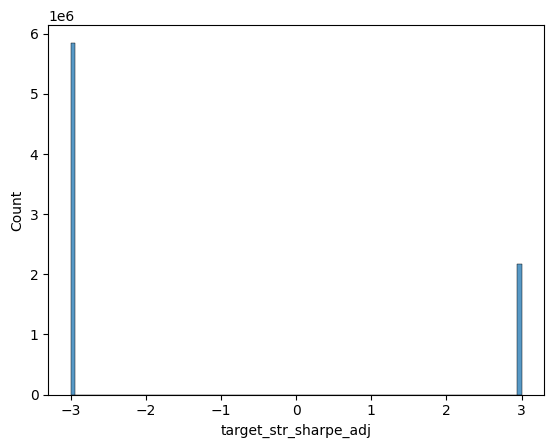

In [7]:
sns.histplot(df['target_str_sharpe_adj'])

In [5]:
df['target_tac_vol_scaled_asym_return_clipped'] = [2.0 if x>2.0 else x for x in df['target_tac_vol_scaled_asym_return_clipped']]

In [6]:
df['target_str_sharpe_adj'] = [3.0 if x>3.0 else x for x in df['target_str_sharpe_adj']]
df['target_str_sharpe_adj'] = [-3.0 if x<3.0 else x for x in df['target_str_sharpe_adj']]

In [6]:
df.to_parquet('../data/master_select/index_meta.parquet')